In [1]:
import re
import pandas as pd
import glob
import os

def procesar_log_detallado(ruta_archivo):
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    # Separamos el log por secciones asociadas a cada dataset
    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    
    resumen_data = []
    clases_data = []
    
    # Extraemos el nombre del método de la primera sección o del log en general si es posible
    # Buscamos la línea: Configuración: Epoch=..., Aumentado=Nombre del Método
    metodo_match_global = re.search(r"Aumentado=(.+)$", texto, re.MULTILINE)

    if metodo_match_global:
        nombre_metodo_defecto = metodo_match_global.group(1).strip().replace("Aumentado=", "")
    else:
        nombre_metodo_defecto = os.path.basename(ruta_archivo).replace(".log", "").replace("Aumentado=", "")

    for seccion in secciones[1:]:
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        # Extraemos métricas
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        tiempo_total_match = re.search(r"Tiempo entrenamiento total medio .*?:\s*([\d.]+)\s*s", seccion)
        tiempo_epoca_match = re.search(r"Tiempo medio por época .*?:\s*([\d.]+)\s*s", seccion)
        
        # Extraemos el método específico de esta sección (por si acaso varía, aunque suele ser el mismo por log)
        metodo_match = re.search(r"Aumentado=(.+)$", seccion, re.MULTILINE)
        nombre_metodo = metodo_match.group(1).strip().replace("Aumentado=", "") if metodo_match else nombre_metodo_defecto

        if oa_match and aa_match:
            datos_dataset = {
                "Método": nombre_metodo,
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "std OA (%)": float(oa_match.group(2)),
                "AA (%)": float(aa_match.group(1)),
                "std AA (%)": float(aa_match.group(2)),
                "Tiempo Total (s)": float(tiempo_total_match.group(1)) if tiempo_total_match else None,
                "Tiempo por Época (s)": float(tiempo_epoca_match.group(1)) if tiempo_epoca_match else None
            }
            resumen_data.append(datos_dataset)
            
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })
    
    if not resumen_data:
        return "No se encontraron datos válidos.", None, None

    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    stats = {
        "Métrica": ["OA Global", "AA Global", "Tiempo Total (s)", "Tiempo por Época (s)"],
        "Media": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean(), df_resumen["Tiempo Total (s)"].mean(), df_resumen["Tiempo por Época (s)"].mean()],
        "Desviación": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std(), df_resumen["Tiempo Total (s)"].std(), df_resumen["Tiempo por Época (s)"].std()]
    }
    df_stats = pd.DataFrame(stats)
    
    # Retornamos también el nombre del método para usarlo en las gráficas
    return df_resumen, df_stats, df_clases_wide, nombre_metodo_defecto

In [2]:
def imprimirResultados(ruta_carpeta):
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))
    datos_comparacion = []

    if not archivos:
        print(f"No se encontraron archivos .log en la carpeta '{ruta_carpeta}'.")
        return []

    for archivo in archivos:
        nombre_archivo = os.path.basename(archivo).replace(".log", "")
        print(f"\n{'='*30} ARCHIVO: {nombre_archivo} {'='*30}")
        
        df_res, df_st, df_clases, nombre_metodo = procesar_log_detallado(archivo)
        
        if isinstance(df_res, pd.DataFrame):
            print("\n************* TABLA RESUMEN (OA/AA): *************")
            print(df_res.to_string(index=False))
            print("\n************* ESTADÍSTICAS GLOBALES: *************")
            print(df_st.to_string(index=False))
            
            oa_global = df_st.loc[df_st['Métrica'] == 'OA Global', 'Media'].values[0]
            aa_global = df_st.loc[df_st['Métrica'] == 'AA Global', 'Media'].values[0]
            oa_std = df_st.loc[df_st['Métrica'] == 'OA Global', 'Desviación'].values[0]
            aa_std = df_st.loc[df_st['Métrica'] == 'AA Global', 'Desviación'].values[0]
            
            t_total_medio = df_st.loc[df_st['Métrica'] == 'Tiempo Total (s)', 'Media'].values[0]
            t_epoca_medio = df_st.loc[df_st['Métrica'] == 'Tiempo por Época (s)', 'Media'].values[0]
            
            datos_comparacion.append({
                "Método": nombre_metodo,  # Usamos el nombre descriptivo extraído
                "OA Global (%)": oa_global,
                "AA Global (%)": aa_global,
                "OA Std (%)": oa_std,
                "AA Std (%)": aa_std,
                "Tiempo Total Medio (s)": t_total_medio,
                "Tiempo Época Medio (s)": t_epoca_medio
            })
        else:
            print(df_res)
        
        if datos_comparacion:
            datos_ordenados = sorted(
                datos_comparacion, 
                key=lambda x: (x["AA Global (%)"], x["OA Global (%)"]), 
                reverse=True
            )
            
            # Nos quedamos con los 5 primeros (o menos si no hay 5 archivos)
            top_5 = datos_ordenados[:5]
            
            print(f"\n\n{'='*25} TOP 5 MEJORES RESULTADOS {'='*25}")
            print(f"{'Ranking':<8} | {'Método':<30} | {'OA Global (%) ± Std':<22} | {'AA Global (%) ± Std':<22}")
            print("-" * 91)
            
            for i, dato in enumerate(top_5, start=1):
                # Formateamos el texto para incluir la media y la desviación estándar
                oa_str = f"{dato['OA Global (%)']:.2f} ± {dato['OA Std (%)']:.2f}"
                aa_str = f"{dato['AA Global (%)']:.2f} ± {dato['AA Std (%)']:.2f}"
                
                print(f"#{i:<7} | {dato['Método']:<30} | {oa_str:<22} | {aa_str:<22}")
                
            print("=" * 91)
    return datos_comparacion

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

def graficaComparacionModelos(datos_comparacion):
    if datos_comparacion:
        df_comparacion = pd.DataFrame(datos_comparacion)

        # 1. Ordenamos por AA y sacamos el Top 7
        if 'AA Global (%)' in df_comparacion.columns:
            df_comparacion = df_comparacion.sort_values(by='AA Global (%)', ascending=False)
        df_comparacion = df_comparacion.head(7)
        
        tiene_tiempos = "Tiempo Total Medio (s)" in df_comparacion.columns and not df_comparacion["Tiempo Total Medio (s)"].isnull().all()
        
        # Tamaño estándar para cada figura individual
        fig_size = (10, 6)

        # ---------------------------------------------------------
        # Gráfica 1: Precisión
        # ---------------------------------------------------------
        # Al pasar figsize directamente al método plot de pandas, nos crea una figura nueva
        ax1 = df_comparacion.set_index('Método')[['OA Global (%)', 'AA Global (%)']].plot(
            kind='bar', color=['#1f77b4', '#ff7f0e'], alpha=0.8, figsize=fig_size
        )
        ax1.set_title('Media Precisión Global (OA y AA) - TOP 5', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Precisión (%)')
        ax1.set_ylim(80, 100)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        ax1.legend(["OA Global", "AA Global"], loc='upper right')
        
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Métodos de Aumentado')
        plt.tight_layout()
        plt.show() # Muestra la primera gráfica y la cierra

        # ---------------------------------------------------------
        # Gráfica 2: Desviación
        # ---------------------------------------------------------
        ax2 = df_comparacion.set_index('Método')[['OA Std (%)', 'AA Std (%)']].plot(
            kind='bar', color=['#2ca02c', '#d62728'], alpha=0.8, figsize=fig_size
        )
        ax2.set_title('Desviación estándar (OA y AA) - TOP 5', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Variación (%)')
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        ax2.legend(["OA Std", "AA Std"], loc='upper right')
        
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Métodos de Aumentado')
        plt.tight_layout()
        plt.show() # Muestra la segunda gráfica y la cierra

        # ---------------------------------------------------------
        # Gráfica 3: Tiempos (solo si existe)
        # ---------------------------------------------------------
        if tiene_tiempos:
            ax3 = df_comparacion.set_index('Método')[['Tiempo Época Medio (s)']].plot(
                kind='bar', color=['#8c564b'], alpha=0.8, figsize=fig_size
            )
            ax3.set_title('Coste Computacional (Tiempo Medio por Época) - TOP 5', fontsize=14, fontweight='bold')
            ax3.set_ylabel('Tiempo (segundos)')
            ax3.set_ylim(bottom=0)
            ax3.grid(axis='y', linestyle='--', alpha=0.5)
            ax3.legend(["Tiempo Medio por Época"], loc='upper right')
            
            plt.xticks(rotation=45, ha='right')
            plt.xlabel('Métodos de Aumentado')
            plt.tight_layout()
            plt.show() # Muestra la tercera gráfica y la cierra

## Resultados usando el aumentado de la clase minoritaria en el dataloader

In [9]:
ruta_carpeta = "Codigos_AumentadosPyTorch/resultadosAumentado_PyTorch"

datos_comparacion=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: metodo_0_Sin_Aumentado ==============================

************* TABLA RESUMEN (OA/AA): *************
                             Método         Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)  Tiempo Total (s)  Tiempo por Época (s)
0, Sin aumentado extra (solo Flips)         oitaven   95.10        0.19   92.05        0.64             52.38                0.5238
0, Sin aumentado extra (solo Flips)      das_mestas   90.81        0.11   88.51        0.41             93.11                0.9311
0, Sin aumentado extra (solo Flips)       eiras_dam   95.38        0.28   89.08        1.86             38.80                0.3880
0, Sin aumentado extra (solo Flips)   ermidas_creek   98.03        0.13   95.93        1.05             58.76                0.5876
0, Sin aumentado extra (solo Flips) ferreiras_river   91.37        0.11   78.38        1.50            132.62                1.3262
0, Sin aumentado extra (solo Flips)      mera_river   90.64  

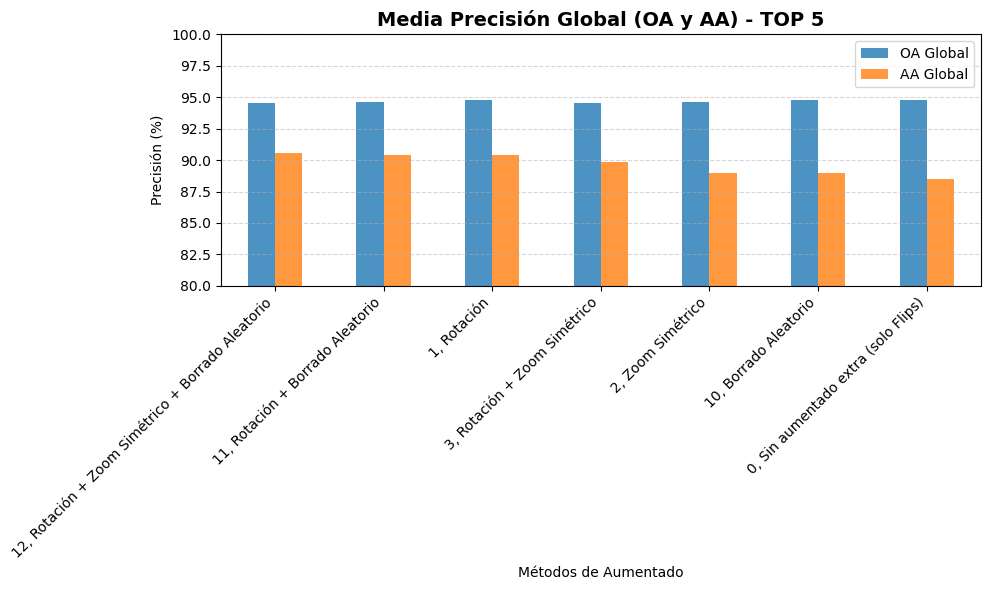

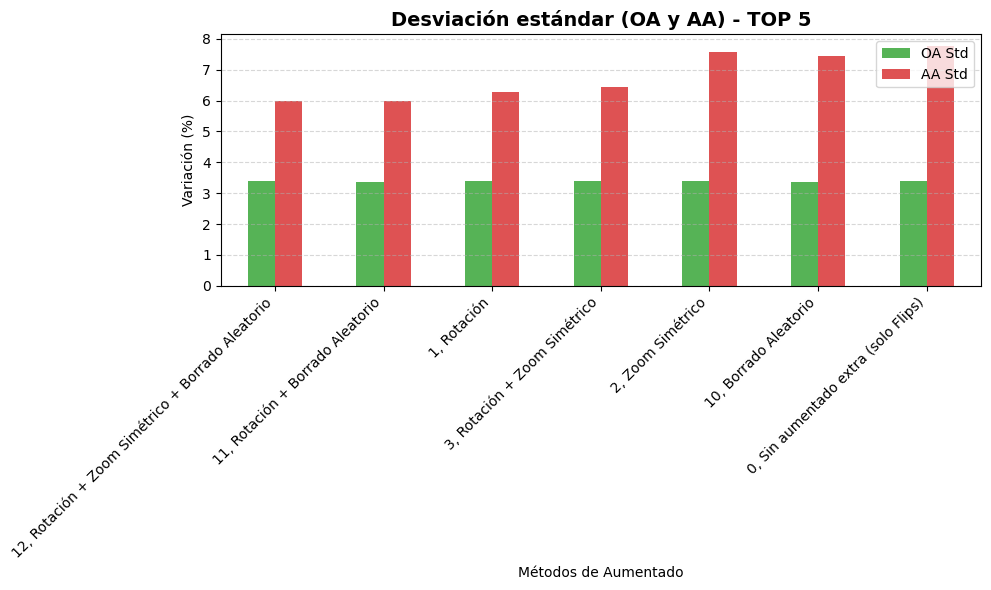

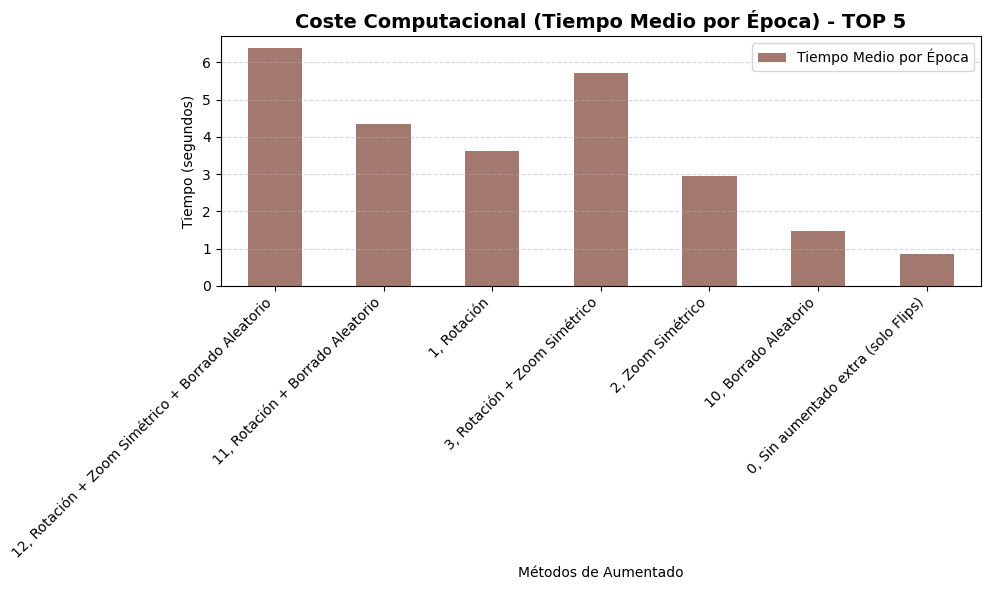

In [10]:
graficaComparacionModelos(datos_comparacion)

# Comportamiento de las distintas versiones por cada dataset

In [21]:
def graficar_clases_por_dataset(dataset_objetivo, top_7_nombres, ruta_carpeta="resultados_logs"):
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))
    df_clases_metodos = pd.DataFrame()

    for archivo in archivos:
        df_res, _, df_clases, nombre_metodo = procesar_log_detallado(archivo)
        
        # SOLO procesamos si el método está en nuestra lista de mejores 7
        if nombre_metodo in top_7_nombres:
            if isinstance(df_clases, pd.DataFrame) and dataset_objetivo in df_clases.index:
                df_clases_metodos[nombre_metodo] = df_clases.loc[dataset_objetivo]

    if df_clases_metodos.empty:
        return

    # Limpieza de datos (ceros y NaNs)
    df_clases_metodos = df_clases_metodos.dropna(how='all')
    df_clases_metodos = df_clases_metodos[(df_clases_metodos > 0).any(axis=1)]

    # Graficar
    fig, ax = plt.subplots(figsize=(15, 7))
    # Ordenamos las columnas según el orden del top_7_nombres para que la leyenda sea coherente
    columnas_ordenadas = [m for m in top_7_nombres if m in df_clases_metodos.columns]
    df_clases_metodos[columnas_ordenadas].plot(kind='bar', ax=ax, width=0.85, colormap='tab10')

    ax.set_title(f'Dataset: {dataset_objetivo} - Precisión Clases (TOP 7 AA)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(bottom=df_clases_metodos.min().min() * 0.9) # Ajuste dinámico de escala
    ax.legend(title="Top Métodos", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

def ejecutar_graficas_dinamicas_filtradas(ruta_carpeta, top_7_nombres):
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))
    if not archivos: return
        
    # Obtener nombres de datasets del primer log
    _, _, df_clases_ejemplo, _ = procesar_log_detallado(archivos[0])
    
    if isinstance(df_clases_ejemplo, pd.DataFrame):
        datasets_disponibles = df_clases_ejemplo.index.tolist()
        for ds in datasets_disponibles:
            graficar_clases_por_dataset(ds, top_7_nombres, ruta_carpeta)

Modelos seleccionados (Top 4 + inicial 0): ['12, Rotación + Zoom Simétrico + Borrado Aleatorio', '11, Rotación + Borrado Aleatorio', '1, Rotación', '3, Rotación + Zoom Simétrico', '0, Sin aumentado extra (solo Flips)']


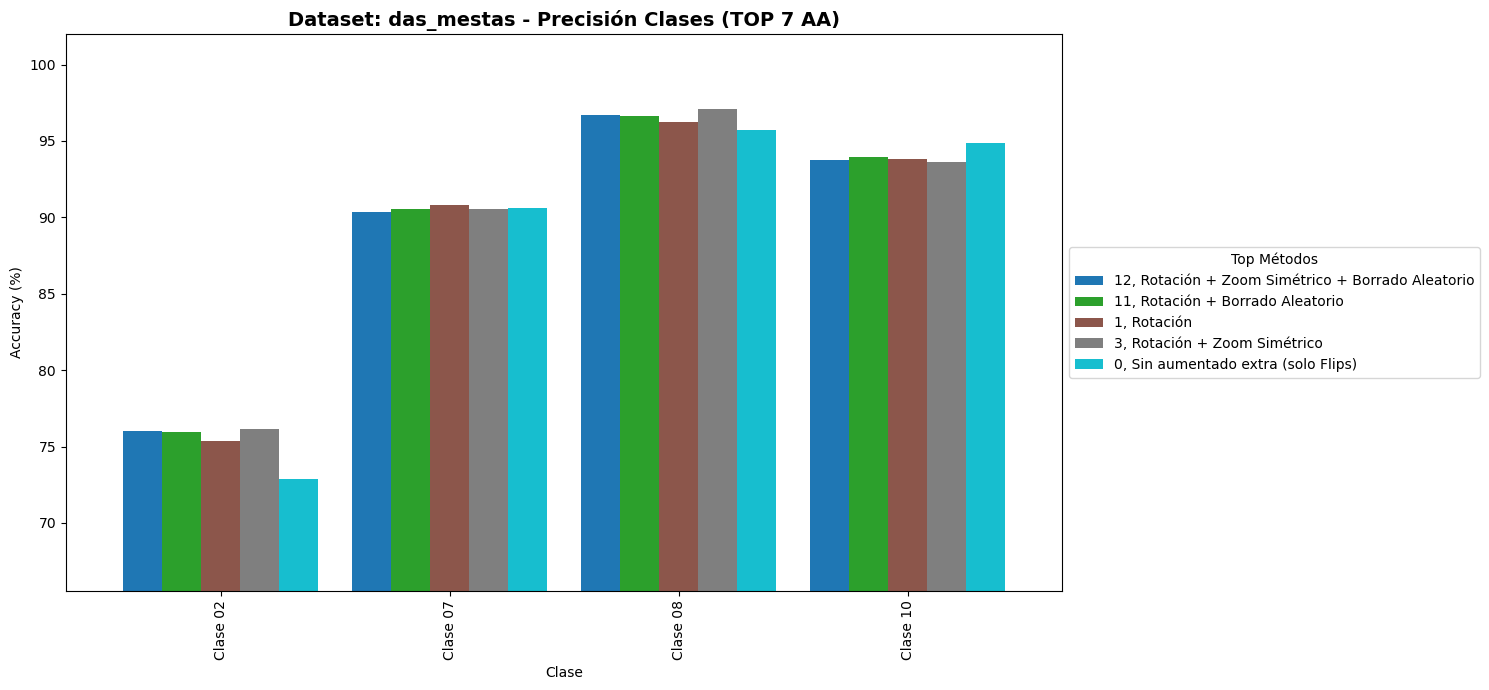

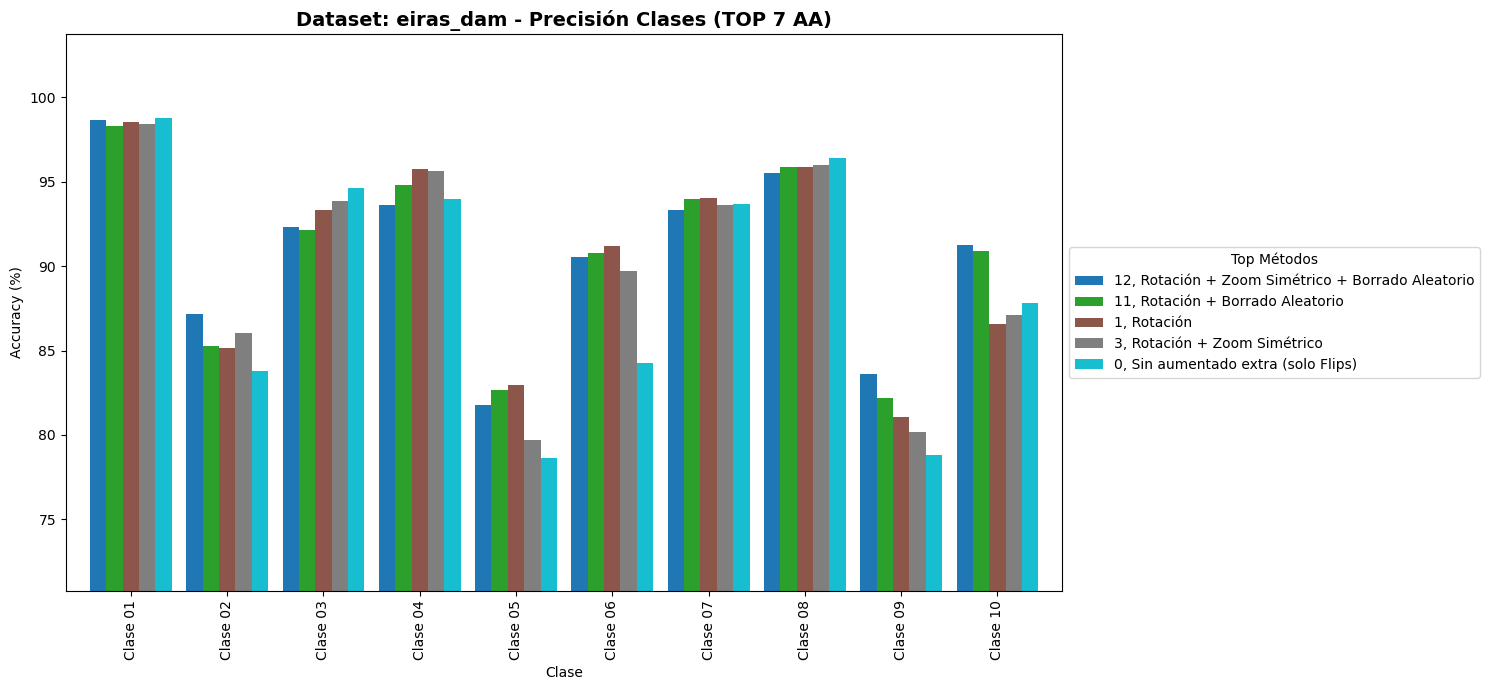

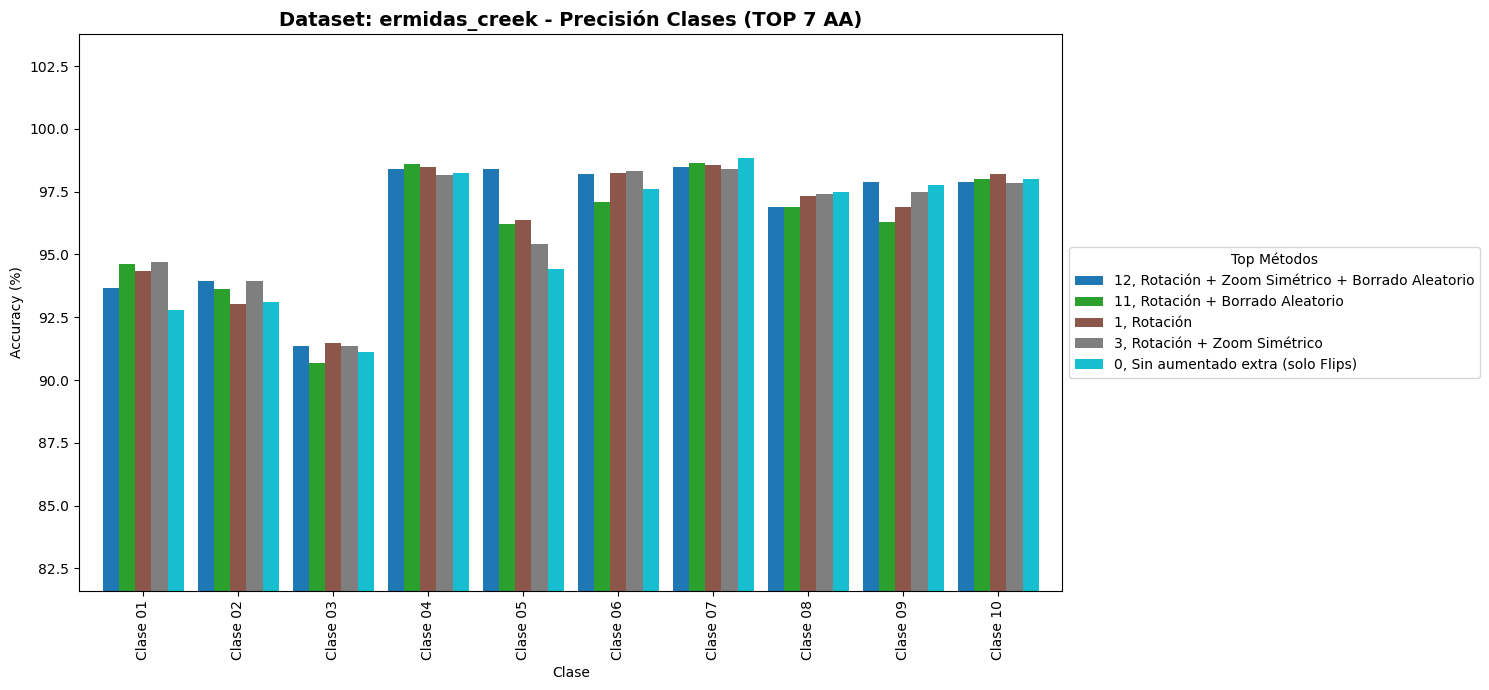

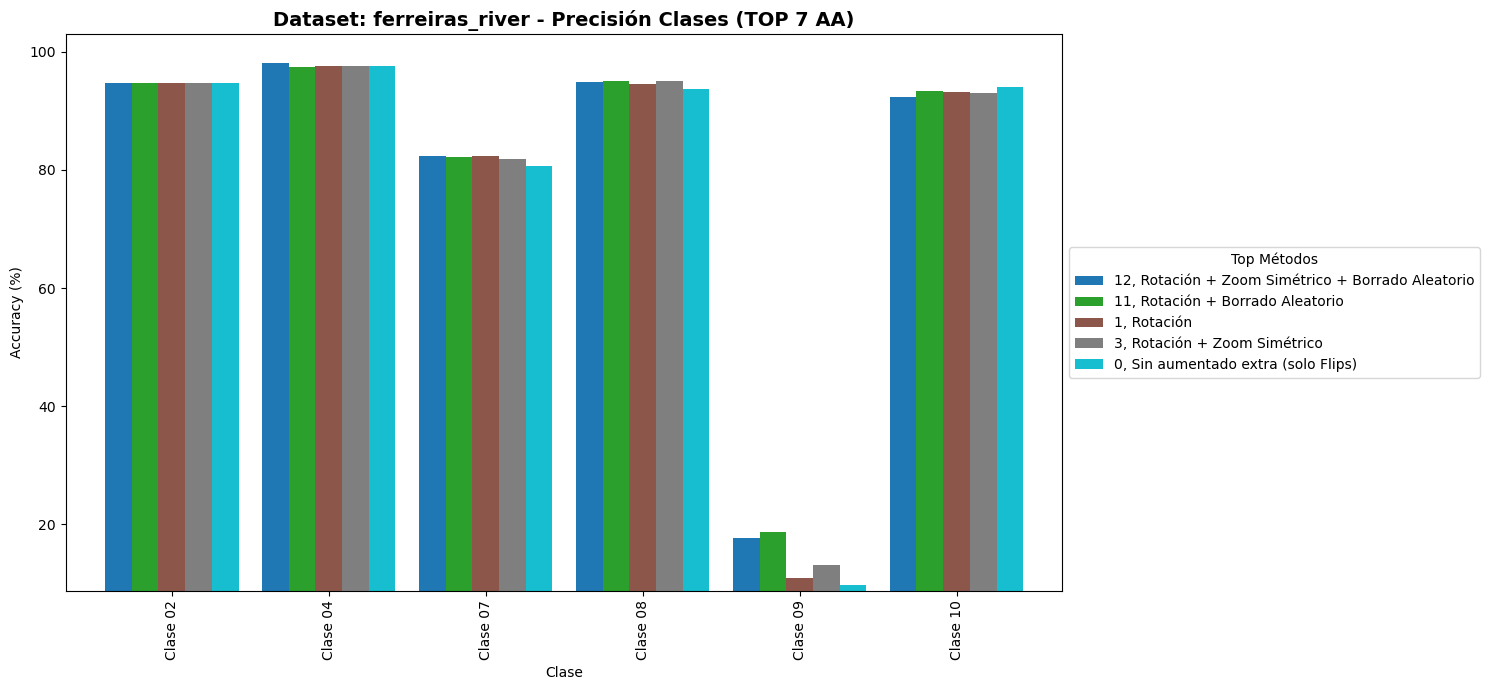

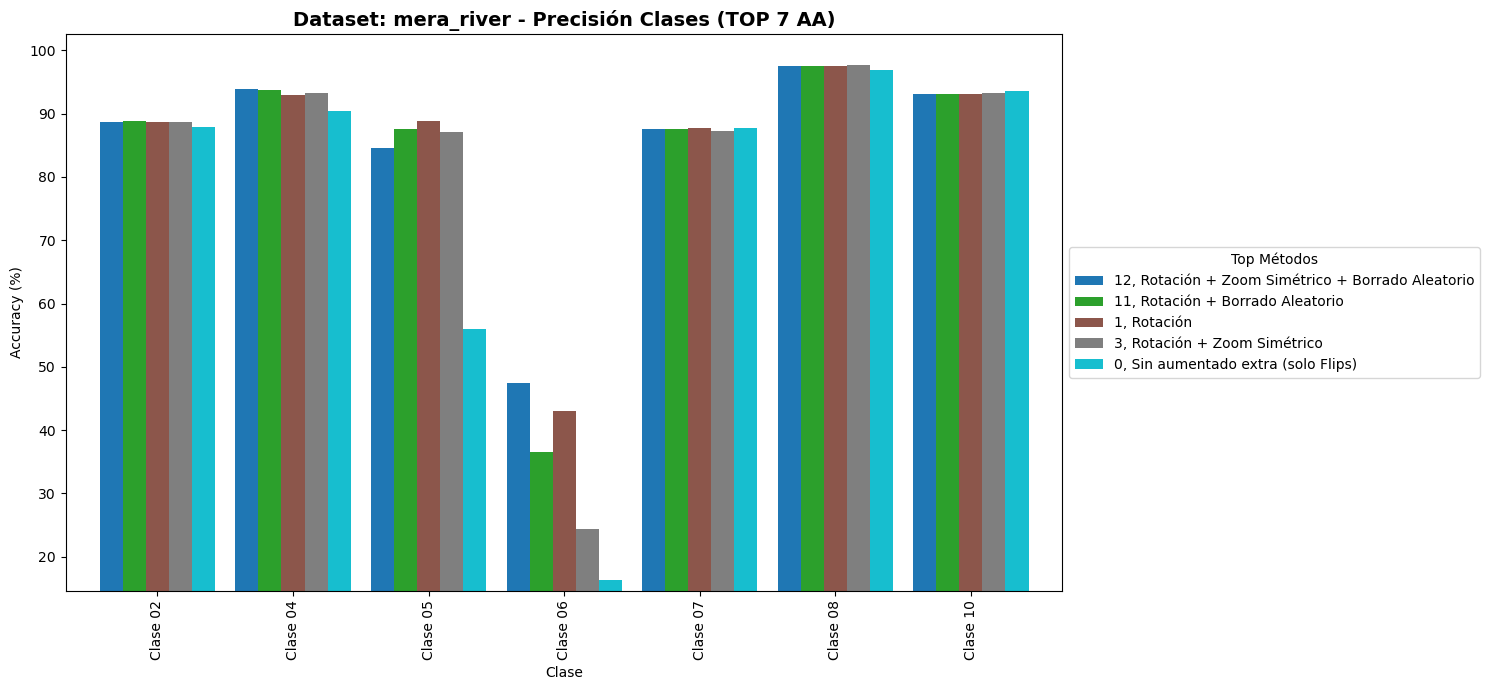

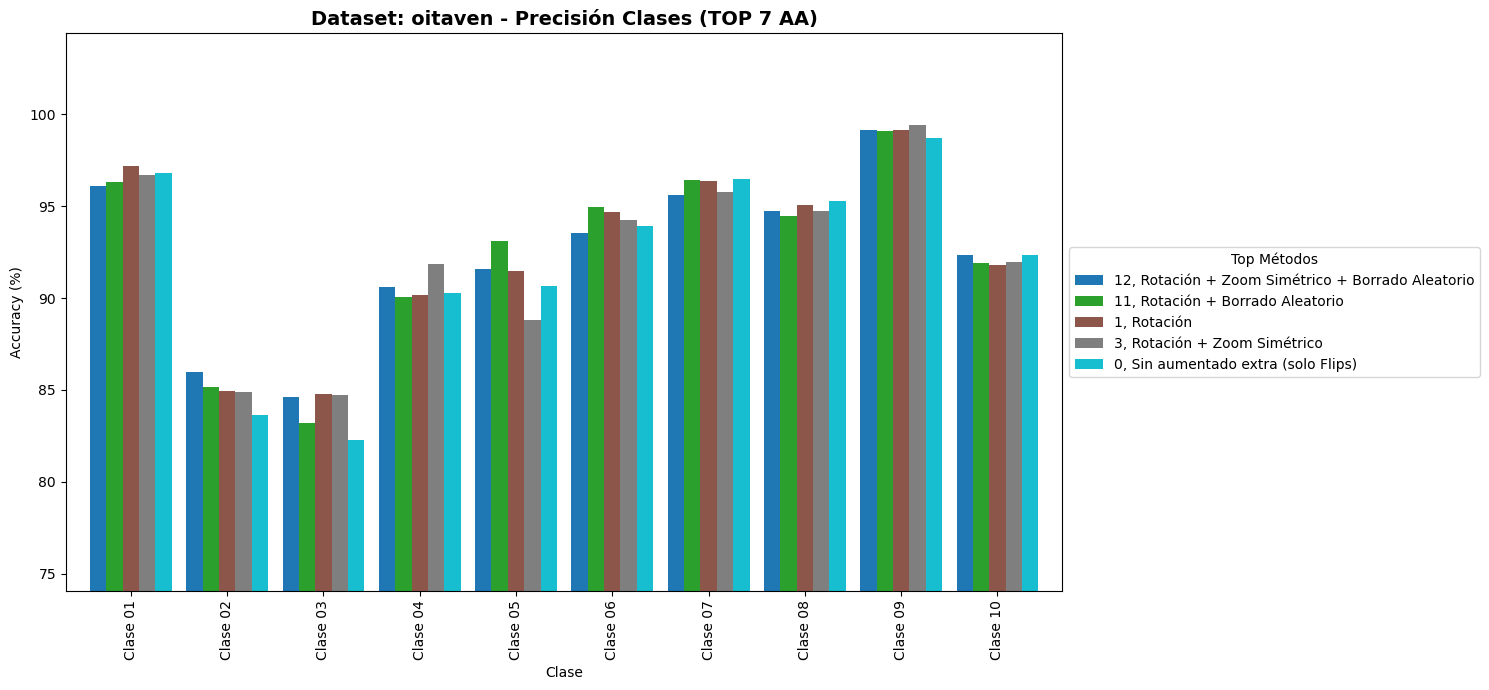

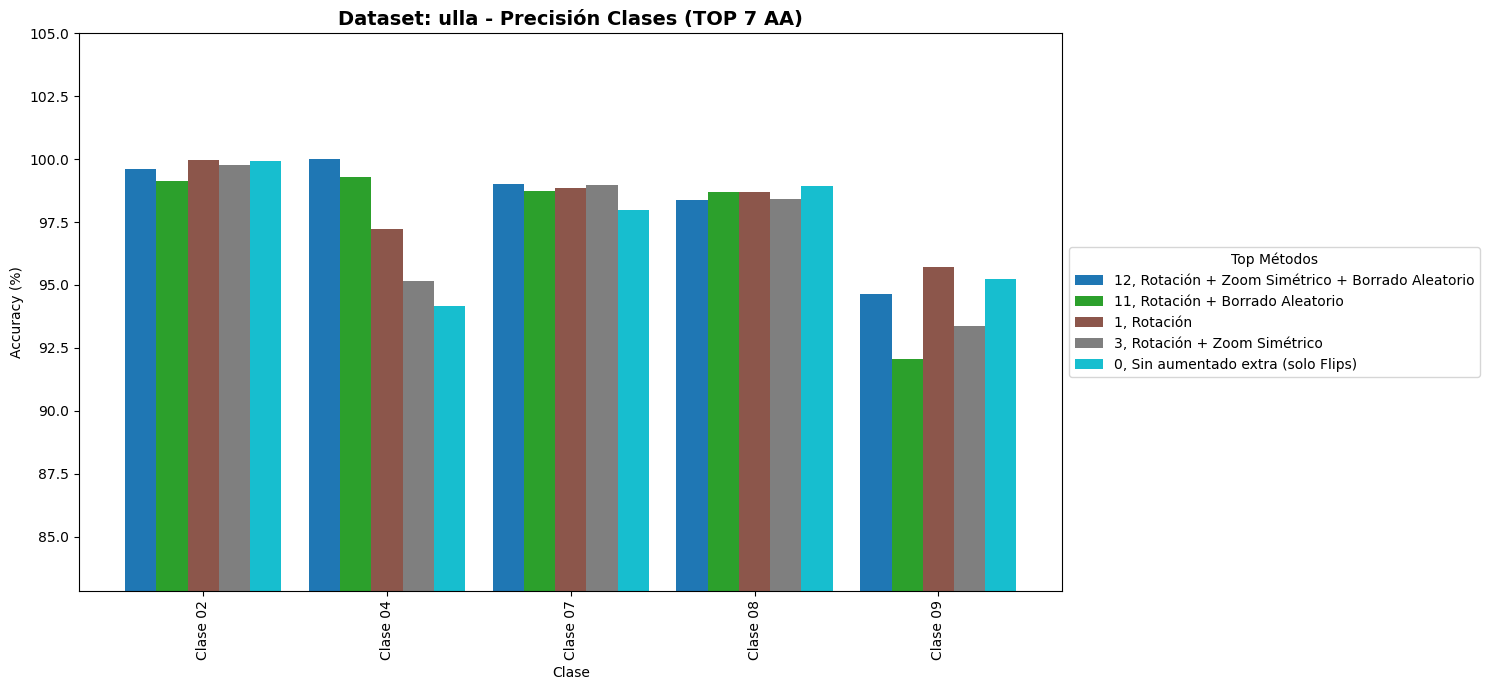

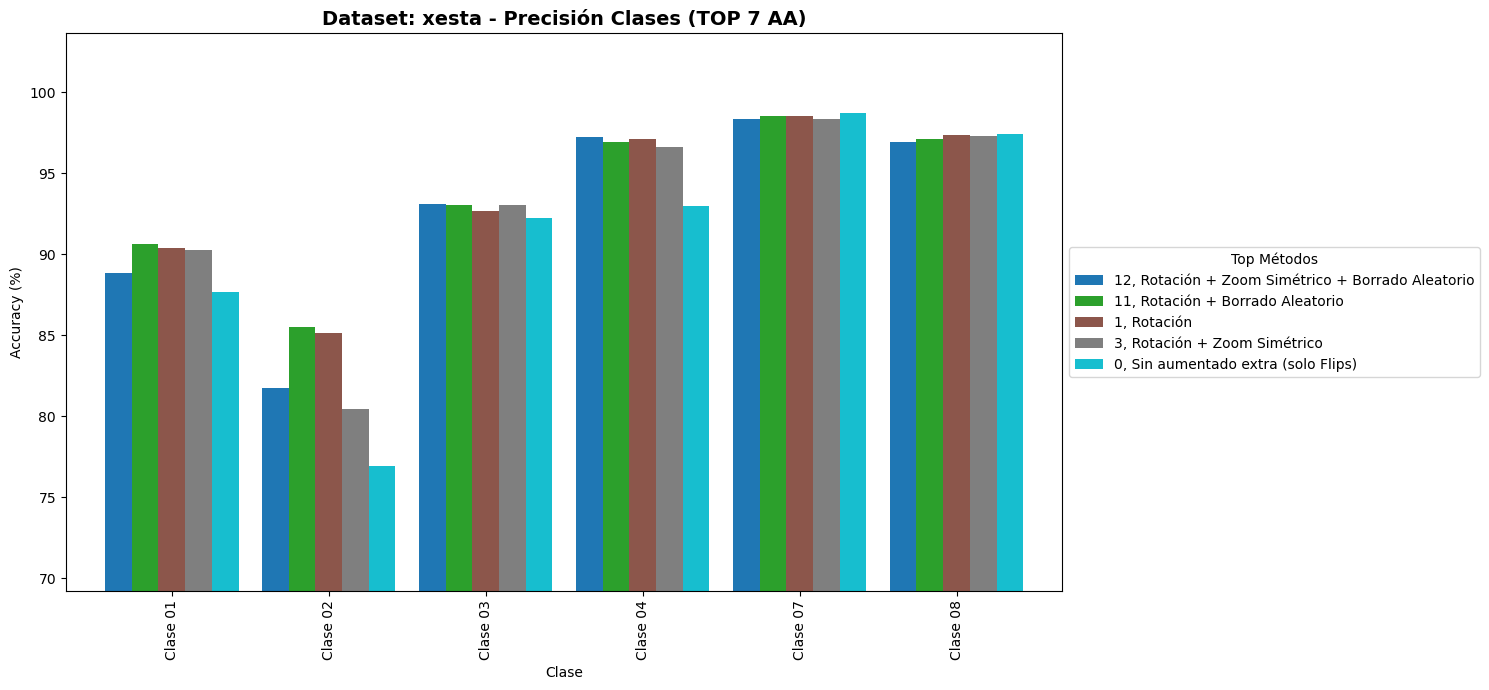

In [26]:
# 1. Definir la ruta
ruta_carpeta = "Codigos_AumentadosPyTorch/resultadosAumentado_PyTorch"

# 3. Extraer la lista personalizada (Top 4 + el que empieza por "0")
if datos_comparacion:
    df_temp = pd.DataFrame(datos_comparacion)
    
    # A) Obtenemos los nombres de los 4 mejores según AA Global
    top_4_nombres = df_temp.sort_values(by='AA Global (%)', ascending=False).head(4)['Método'].tolist()
    
    # B) Buscamos el método que empieza por "0"
    # Usamos str(m).startswith('0') para asegurar que encuentre "0", "0_algo", etc.
    metodos_con_cero = [m for m in df_temp['Método'].unique() if str(m).startswith('0')]
    
    # C) Combinamos ambas listas sin duplicados
    # Esto mantiene los top 4 y añade el que empieza por 0 si no estaba ya ahí
    top_final_nombres = list(dict.fromkeys(top_4_nombres + metodos_con_cero))
    
    print(f"Modelos seleccionados (Top 4 + inicial 0): {top_final_nombres}")

    # 5. Llamar a las gráficas por clase filtrando por esta lista
    ejecutar_graficas_dinamicas_filtradas(ruta_carpeta, top_final_nombres)